# 01A · Resumen base de general splits

Seguimiento sencillo del dashboard de equipos (Regular Season 2024-25) usando únicamente el parquet intermedio filtrado por `dataset = 0`. El objetivo es documentar:

- Filtrado del subset válido y verificación Win/Loss por franquicia.
- Tablas básicas de tiro y producción con diferenciales `W − L`.
- Rankings enfocados en anotación, puntería y margen de puntos.
- Visualizaciones descriptivas que resuman el comportamiento ofensivo.

---


## Configuración

Cargamos las dependencias (`pandas`, `matplotlib`, `seaborn`) y definimos rutas relativas tomando como raíz el repositorio. Se crean las carpetas donde se guardarán tablas y figuras del análisis.

---


In [23]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)

NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parents[3]
DATA_DIR = PROJECT_ROOT / "00_data"
FIGURES_DIR = PROJECT_ROOT / "00e_reports" / "figures" / "base_overview"
TABLES_DIR = PROJECT_ROOT / "00e_reports" / "tables" / "base_overview"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

INTERMEDIATE_PATH = (
    DATA_DIR
    / "00b_intermediate"
    / "team_dashboard"
    / "general_splits"
    / "2024-25"
    / "Regular Season"
    / "team_dashboard__general_splits.parquet"
)
DATASET_REFERENCE_ID = 0
SEASON_TARGET = "2024-25"

print(f"Proyecto: {PROJECT_ROOT}")
print(f"Parquet intermedio: {INTERMEDIATE_PATH}")
print(f"Dataset de referencia: {DATASET_REFERENCE_ID}")
print(f"Temporada objetivo: {SEASON_TARGET}")


Proyecto: /Users/pablo/Documents/BigData/BasketballAnalysis
Parquet intermedio: /Users/pablo/Documents/BigData/BasketballAnalysis/00_data/00b_intermediate/team_dashboard/general_splits/2024-25/Regular Season/team_dashboard__general_splits.parquet
Dataset de referencia: 0
Temporada objetivo: 2024-25


## Carga y filtrado de datos

Leemos el parquet consolidado, ubicamos las columnas relevantes (`dataset`, `source_dataset`, `season`) y filtramos el subset solicitado (`dataset = 0`, `source_dataset = 0`, temporada 2024-25). Conservamos una copia completa para referencia rápida.

---


In [24]:
general_df = pd.read_parquet(INTERMEDIATE_PATH)

# Mapa case-insensitive
colmap = {c.lower(): c for c in general_df.columns}

df = general_df.copy()

# --- Filtro por dataset/source_dataset con OR ---
ds_col  = colmap.get("dataset")
sds_col = colmap.get("source_dataset")

if ds_col or sds_col:
    m_ds  = (df[ds_col].astype(str)  == str(DATASET_REFERENCE_ID)) if ds_col  else False
    m_sds = (df[sds_col].astype(str) == str(DATASET_REFERENCE_ID)) if sds_col else False
    df = df[m_ds | m_sds]

# --- Filtro por season (acepta season o season_year) ---
season_col = colmap.get("season") or colmap.get("season_year")
if season_col:
    df = df[df[season_col].astype(str) == str(SEASON_TARGET)]

# (Opcional) Filtro por season_type si lo estás usando
st_col = colmap.get("season_type")
if st_col and "SEASON_TYPE_TARGET" in globals() and SEASON_TYPE_TARGET:
    df = df[df[st_col].astype(str).str.casefold() == str(SEASON_TYPE_TARGET).casefold()]

analysis_df = df.copy()

print("general_df shape:", general_df.shape)
print("analysis_df shape:", analysis_df.shape)
print("dataset uniques:", general_df[colmap.get("dataset")].unique() if colmap.get("dataset") else "no 'dataset'")
print("source_dataset uniques:", general_df[colmap.get("source_dataset")].unique() if colmap.get("source_dataset") else "no 'source_dataset'")
print("season uniques:", general_df[season_col].unique() if season_col else "no season/season_year")


general_df shape: (672, 69)
analysis_df shape: (60, 69)
dataset uniques: ['dataset_0' 'dataset_1' 'dataset_2' 'dataset_3' 'dataset_4' 'dataset_5']
source_dataset uniques: [0 1 2 3 4 5]
season uniques: ['2024-25']


### Vista general del parquet filtrado

Mostramos las primeras filas para confirmar que únicamente quedan registros de la temporada objetivo y que se mantienen las columnas de tiro y producción solicitadas.

---


In [25]:
display(analysis_df.head())


,GROUP_SET,GROUP_VALUE,SEASON_YEAR,GP,W,L,W_PCT,MIN,FGM,FGA,...,dataset,TEAM_NAME,source_dataset,split_type,split_value,TEAM_GAME_LOCATION,GAME_RESULT,SEASON_MONTH_NAME,SEASON_SEGMENT,TEAM_DAYS_REST_RANGE
0,Overall,2024,2024,5,0,5,0.000,201.883333,140,357,...,dataset_0,Atlanta Hawks,0,overall,overall,None,None,None,None,None
1,Overall,2024-25,2024-25,82,40,42,0.488,3956.000000,3556,7528,...,dataset_0,Atlanta Hawks,0,overall,overall,None,None,None,None,None
2,Overall,2024,2024,5,2,3,0.400,200.000000,172,379,...,dataset_0,Boston Celtics,0,overall,overall,None,None,None,None,None
3,Overall,2024-25,2024-25,82,61,21,0.744,3966.000000,3413,7382,...,dataset_0,Boston Celtics,0,overall,overall,None,None,None,None,None
4,Overall,2024,2024,5,2,3,0.400,200.000000,169,372,...,dataset_0,Cleveland Cavaliers,0,overall,overall,None,None,None,None,None


## Normalización ligera de columnas

Para facilitar los cálculos posteriores trabajamos con una versión que usa nombres en mayúsculas. El DataFrame original se preserva para cualquier inspección adicional.

---


In [26]:
analysis_std = analysis_df.rename(columns={col: col.upper() for col in analysis_df.columns})
COLUMN_LOOKUP = {col: col for col in analysis_std.columns}

def require_columns(labels):
    missing = [label for label in labels if label not in COLUMN_LOOKUP]
    if missing:
        raise KeyError(f"Columnas faltantes en el parquet filtrado: {missing}")
    return [COLUMN_LOOKUP[label] for label in labels]

TEAM_KEYS = require_columns(["TEAM_ID", "TEAM_NAME"])
#RESULT_COL = require_columns(["GAME_RESULT"])[0]


## Validación Win/Loss por franquicia

Comprobamos que cada equipo disponga de exactamente dos filas (una victoria `W` y una derrota `L`). Reportamos el número de resultados distintos por equipo y resaltamos cualquier caso atípico.

---


In [27]:
win_loss_counts = (
    analysis_std
    .groupby(TEAM_KEYS, dropna=False)[["W", "L"]]
    .sum(min_count=1)   # suma por equipo
)

win_loss_summary = win_loss_counts.assign(TOTAL=lambda df: df["W"] + df["L"])

anomalies = win_loss_summary[
    (win_loss_summary["W"] == 0) | (win_loss_summary["L"] == 0)
]

display(win_loss_summary)
print("Shape:", win_loss_summary.shape)
print(win_loss_summary.head())

if not anomalies.empty:
    print("⚠️ Equipos sin par W/L completo:")
    display(anomalies)
else:
    print("✅ Todos los equipos tienen registros de victoria y derrota.")


,,W,L,TOTAL
TEAM_ID,TEAM_NAME,,,
1610612737,Atlanta Hawks,40,47,87
1610612738,Boston Celtics,63,24,87
1610612739,Cleveland Cavaliers,66,21,87
1610612740,New Orleans Pelicans,21,66,87
1610612741,Chicago Bulls,41,46,87
1610612742,Dallas Mavericks,40,47,87
1610612743,Denver Nuggets,52,35,87
1610612744,Golden State Warriors,55,35,90
1610612745,Houston Rockets,54,33,87


Shape: (30, 3)
                                  W   L  TOTAL
TEAM_ID    TEAM_NAME                          
1610612737 Atlanta Hawks         40  47     87
1610612738 Boston Celtics        63  24     87
1610612739 Cleveland Cavaliers   66  21     87
1610612740 New Orleans Pelicans  21  66     87
1610612741 Chicago Bulls         41  46     87
✅ Todos los equipos tienen registros de victoria y derrota.


## Tablas de tiro y producción (W vs L)

Construimos tablas para victorias y derrotas con métricas básicas de anotación y juego colectivo. También calculamos el diferencial \( \Delta = 	ext{W} - 	ext{L} \) para cada métrica, incluyendo un campo \(W_{	ext{total}} - L_{	ext{total}}\) que resume el margen agregado.

Las métricas analizadas son:

- Volumen: `GP`, `MIN`, `FGM`, `FGA`, `FG3M`, `FG3A`, `FTM`, `FTA`, `OREB`, `DREB`, `REB`, `AST`, `TOV`, `PTS`.
- Eficiencia: `W_PCT`, `FG_PCT`, `FG3_PCT`, `FT_PCT`, `PLUS_MINUS`.

---


In [28]:
metricas = [
    "GP", "W", "L", "W_PCT", "MIN",
    "FGM", "FGA", "FG_PCT",
    "FG3M", "FG3A", "FG3_PCT",
    "FTM", "FTA", "FT_PCT",
    "OREB", "DREB", "REB",
    "AST", "TOV",
    "PTS", "PLUS_MINUS",
]
metric_cols = require_columns(metricas)
metrics_map = dict(zip(metricas, metric_cols))

# Agregado por equipo (no hay splits W/L por fila)
base = (
    analysis_std
    .sort_values(COLUMN_LOOKUP["TEAM_NAME"])
    .groupby(TEAM_KEYS, dropna=False)
    .agg({
        metrics_map["GP"]: "sum",
        metrics_map["W"]: "sum",
        metrics_map["L"]: "sum",
        metrics_map["MIN"]: "sum",
        metrics_map["FGM"]: "sum",
        metrics_map["FGA"]: "sum",
        metrics_map["FG3M"]: "sum",
        metrics_map["FG3A"]: "sum",
        metrics_map["FTM"]: "sum",
        metrics_map["FTA"]: "sum",
        metrics_map["OREB"]: "sum",
        metrics_map["DREB"]: "sum",
        metrics_map["REB"]: "sum",
        metrics_map["AST"]: "sum",
        metrics_map["TOV"]: "sum",
        metrics_map["PTS"]: "sum",
        metrics_map["PLUS_MINUS"]: "sum",  # si prefieres media, cambia a "mean"
    })
)

# Recalcular porcentajes a partir de intentos/encestes
base["W_PCT"]   = base[metrics_map["W"]]   / base[metrics_map["GP"]]
base["FG_PCT"]  = (base[metrics_map["FGM"]]  / base[metrics_map["FGA"]]).where(base[metrics_map["FGA"]]!=0, 0)
base["FG3_PCT"] = (base[metrics_map["FG3M"]] / base[metrics_map["FG3A"]]).where(base[metrics_map["FG3A"]]!=0, 0)
base["FT_PCT"]  = (base[metrics_map["FTM"]]  / base[metrics_map["FTA"]]).where(base[metrics_map["FTA"]]!=0, 0)

# Diferencial simple W-L
base["W_MINUS_L"] = base[metrics_map["W"]] - base[metrics_map["L"]]

# Orden de columnas de salida
cols_out = [
    metrics_map["W"], metrics_map["L"], "W_MINUS_L",
    metrics_map["GP"], "W_PCT",
    metrics_map["MIN"],
    metrics_map["FGM"], metrics_map["FGA"], "FG_PCT",
    metrics_map["FG3M"], metrics_map["FG3A"], "FG3_PCT",
    metrics_map["FTM"], metrics_map["FTA"], "FT_PCT",
    metrics_map["OREB"], metrics_map["DREB"], metrics_map["REB"],
    metrics_map["AST"], metrics_map["TOV"],
    metrics_map["PTS"], metrics_map["PLUS_MINUS"],
]
summary_table = base[cols_out].rename(columns={v: k for k, v in metrics_map.items()})

summary_reset = summary_table.reset_index()
display(summary_reset.head())

summary_path = TABLES_DIR / "resumen_w_l_metrics.csv"
summary_reset.to_csv(summary_path, index=False)
print("Resumen exportado a", summary_path)


,TEAM_ID,TEAM_NAME,W,L,W_MINUS_L,GP,W_PCT,MIN,FGM,FGA,...,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,PTS,PLUS_MINUS
0,1610612737,Atlanta Hawks,40,47,-7,87,0.459770,4157.883333,3696,7885,...,1556,2024,0.768775,1028,2818,3846,2519,1366.0,10122,-115.0
1,1610612738,Boston Celtics,63,24,39,87,0.724138,4166.000000,3585,7761,...,1331,1674,0.795102,1001,2899,3900,2249,1040.0,10013,745.0
2,1610612739,Cleveland Cavaliers,66,21,45,87,0.758621,4151.000000,3821,7816,...,1469,1891,0.776838,964,2948,3912,2416,1167.0,10464,778.0
3,1610612740,New Orleans Pelicans,21,66,-45,87,0.241379,4151.000000,3473,7699,...,1439,1905,0.755381,1039,2706,3745,2200,1294.0,9410,-810.0
4,1610612741,Chicago Bulls,41,46,-5,87,0.471264,4152.883333,3690,7909,...,1406,1746,0.805269,877,3052,3929,2465,1283.0,10099,-161.0


Resumen exportado a /Users/pablo/Documents/BigData/BasketballAnalysis/00e_reports/tables/base_overview/resumen_w_l_metrics.csv


## Rankings enfocados en anotación y margen

Generamos tres rankings:

1. Diferencial de puntos (`PTS_DIFF`).
2. Mejora de porcentaje de campo (`FG_PCT_DIFF`).
3. Margen de `PLUS_MINUS_DIFF`.

Cada tabla incluye la posición (`rank`) calculada con el método *dense* para facilitar comparaciones.

---


In [29]:
# Usamos el resumen actual (sin columnas *_DIFF)
diff_reset = summary_table.reset_index()

# (metric buscada, orden ascendente?, fichero, alternativa si no existe)
rank_specs = [
    ("PTS_DIFF", False, "ranking_pts_diff.csv", "PTS"),
    ("FG_PCT_DIFF", False, "ranking_fg_pct_diff.csv", "FG_PCT"),
    ("PLUS_MINUS_DIFF", False, "ranking_plus_minus_diff.csv", "PLUS_MINUS"),
]

rank_results = {}
for desired_metric, ascending, filename, fallback in rank_specs:
    # Eligimos la métrica disponible: *_DIFF si existe, si no el fallback
    metric = desired_metric if desired_metric in diff_reset.columns else fallback
    if metric not in diff_reset.columns:
        print(f"⚠️ No existe ni '{desired_metric}' ni su alternativa '{fallback}'. Omito ranking.")
        continue

    ranked = (
        diff_reset
        .sort_values(metric, ascending=ascending)
        .assign(**{f"{metric}_RANK": lambda df, m=metric, asc=ascending: df[m].rank(method="dense", ascending=asc).astype(int)})
        .rename(columns={metric: desired_metric if desired_metric != metric else metric})  # renombra a *_DIFF si venimos del fallback
    )
    rank_results[desired_metric] = ranked

    output_path = TABLES_DIR / filename
    ranked.to_csv(output_path, index=False)
    print(f"Ranking usando '{metric}' (objetivo '{desired_metric}') exportado a {output_path}")

for metric, ranked in rank_results.items():
    display(ranked.head())


Ranking usando 'PTS' (objetivo 'PTS_DIFF') exportado a /Users/pablo/Documents/BigData/BasketballAnalysis/00e_reports/tables/base_overview/ranking_pts_diff.csv
Ranking usando 'FG_PCT' (objetivo 'FG_PCT_DIFF') exportado a /Users/pablo/Documents/BigData/BasketballAnalysis/00e_reports/tables/base_overview/ranking_fg_pct_diff.csv
Ranking usando 'PLUS_MINUS' (objetivo 'PLUS_MINUS_DIFF') exportado a /Users/pablo/Documents/BigData/BasketballAnalysis/00e_reports/tables/base_overview/ranking_plus_minus_diff.csv


,TEAM_ID,TEAM_NAME,W,L,W_MINUS_L,GP,W_PCT,MIN,FGM,FGA,...,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,PTS_DIFF,PLUS_MINUS,PTS_RANK
26,1610612763,Memphis Grizzlies,54,37,17,91,0.593407,4307.800000,3989,8370,...,2121,0.782650,1173,3036,4209,2512,1403.0,10859,451.0,1
23,1610612760,Oklahoma City Thunder,71,19,52,90,0.788889,4261.000000,3900,8200,...,1815,0.812121,947,3034,3981,2355,1091.0,10563,1018.0,2
2,1610612739,Cleveland Cavaliers,66,21,45,87,0.758621,4151.000000,3821,7816,...,1891,0.776838,964,2948,3912,2416,1167.0,10464,778.0,3
6,1610612743,Denver Nuggets,52,35,17,87,0.597701,4171.000000,3856,7710,...,2017,0.774417,959,2978,3937,2620,1233.0,10304,316.0,4
0,1610612737,Atlanta Hawks,40,47,-7,87,0.459770,4157.883333,3696,7885,...,2024,0.768775,1028,2818,3846,2519,1366.0,10122,-115.0,5


,TEAM_ID,TEAM_NAME,W,L,W_MINUS_L,GP,W_PCT,MIN,FGM,FGA,...,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,PTS,PLUS_MINUS,FG_PCT_RANK
6,1610612743,Denver Nuggets,52,35,17,87,0.597701,4171.000000,3856,7710,...,2017,0.774417,959,2978,3937,2620,1233.0,10304,316.0,1
2,1610612739,Cleveland Cavaliers,66,21,45,87,0.758621,4151.000000,3821,7816,...,1891,0.776838,964,2948,3912,2416,1167.0,10464,778.0,2
17,1610612754,Indiana Pacers,51,36,15,87,0.586207,4174.583333,3731,7695,...,1897,0.783869,809,2817,3626,2500,1190.0,10075,152.0,3
15,1610612752,New York Knicks,54,33,21,87,0.620690,4176.000000,3718,7672,...,1810,0.797790,926,2754,3680,2352,1170.0,9956,335.0,4
12,1610612749,Milwaukee Bucks,48,39,9,87,0.551724,4151.000000,3605,7463,...,1995,0.746366,720,3033,3753,2188,1185.0,9908,113.0,5


,TEAM_ID,TEAM_NAME,W,L,W_MINUS_L,GP,W_PCT,MIN,FGM,FGA,...,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,PTS,PLUS_MINUS_DIFF,PLUS_MINUS_RANK
23,1610612760,Oklahoma City Thunder,71,19,52,90,0.788889,4261.0,3900,8200,...,1815,0.812121,947,3034,3981,2355,1091.0,10563,1018.0,1
2,1610612739,Cleveland Cavaliers,66,21,45,87,0.758621,4151.0,3821,7816,...,1891,0.776838,964,2948,3912,2416,1167.0,10464,778.0,2
1,1610612738,Boston Celtics,63,24,39,87,0.724138,4166.0,3585,7761,...,1674,0.795102,1001,2899,3900,2249,1040.0,10013,745.0,3
13,1610612750,Minnesota Timberwolves,53,34,19,87,0.609195,4166.0,3533,7572,...,1937,0.784719,971,2851,3822,2248,1262.0,9856,451.0,4
26,1610612763,Memphis Grizzlies,54,37,17,91,0.593407,4307.8,3989,8370,...,2121,0.782650,1173,3036,4209,2512,1403.0,10859,451.0,4


## ΔPTS por equipo

Gráfico de barras con el diferencial de puntos (victorias − derrotas). Permite identificar rápidamente qué equipos amplían su anotación cuando ganan.

---


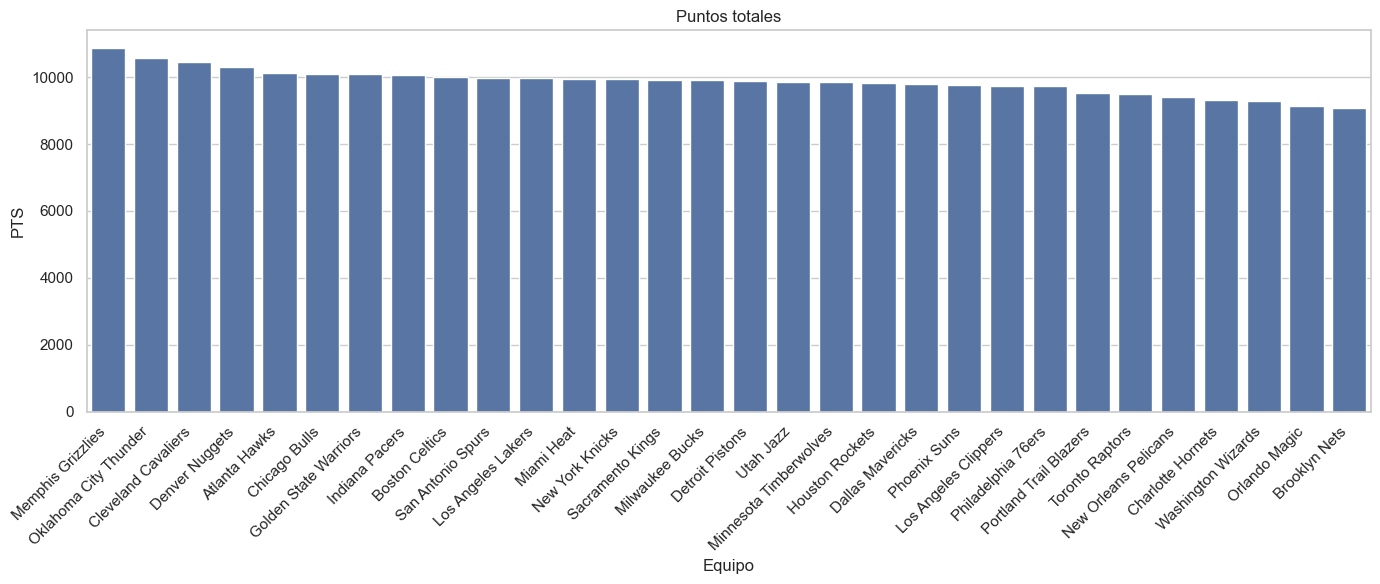

Figura guardada en /Users/pablo/Documents/BigData/BasketballAnalysis/00e_reports/figures/base_overview/bar_pts.png


In [30]:
pts_metric = "PTS_DIFF" if "PTS_DIFF" in diff_reset.columns else "PTS"

if pts_metric in diff_reset.columns:
    bar_df = diff_reset.sort_values(pts_metric, ascending=False)
    fig, ax = plt.subplots(figsize=(14, 6))
    sns.barplot(data=bar_df, x=COLUMN_LOOKUP["TEAM_NAME"], y=pts_metric, ax=ax)
    ax.set_title("Puntos totales" if pts_metric == "PTS" else "Diferencial de puntos (W − L)")
    ax.set_xlabel("Equipo")
    ax.set_ylabel(pts_metric)
    ax.tick_params(axis="x", labelrotation=45)   # rotación correcta
    plt.setp(ax.get_xticklabels(), ha="right")   # alineación horizontal
    plt.tight_layout()
    figure_path = FIGURES_DIR / ("bar_pts.png" if pts_metric == "PTS" else "bar_pts_diff.png")
    fig.savefig(figure_path, dpi=150)
    plt.show()
    print("Figura guardada en", figure_path)
else:
    print("⚠️ No hay columna válida de puntos para graficar.")


## Correlación de métricas clave

Calculamos una matriz de correlación con variables ofensivas básicas (`W_PCT`, porcentajes de tiro, rebotes, asistencias, pérdidas, puntos y margen). Esto ayuda a identificar qué indicadores se mueven juntos.

---


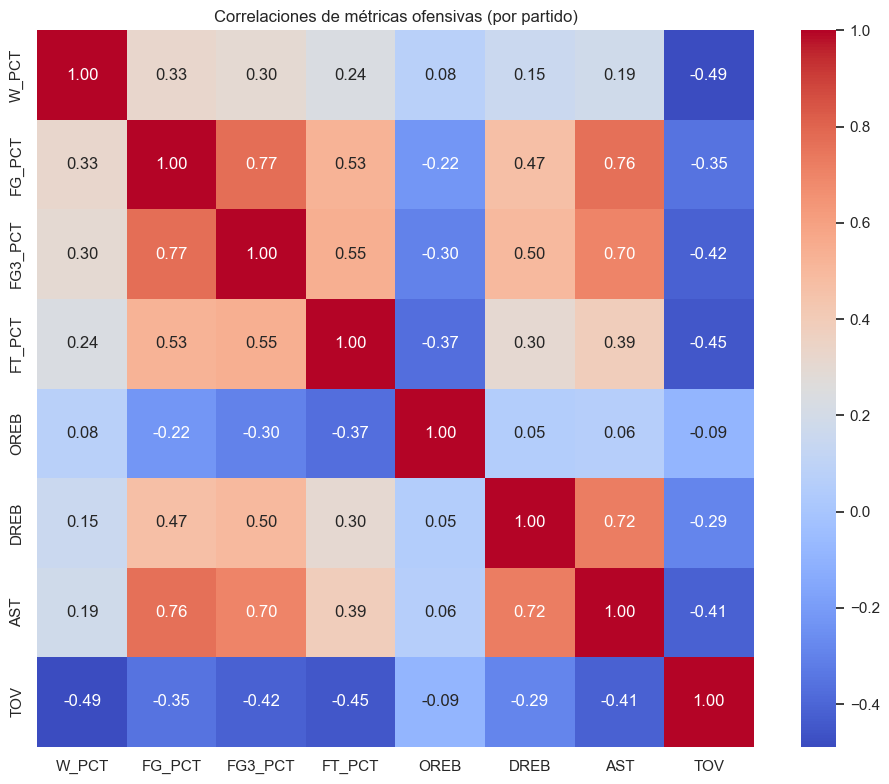

Figura guardada en /Users/pablo/Documents/BigData/BasketballAnalysis/00e_reports/figures/base_overview/heatmap_correlation.png


In [37]:
 corr_metrics = [
    "W_PCT", "FG_PCT", "FG3_PCT", "FT_PCT",
    "OREB", "DREB",
    "AST", "TOV",
]
corr_cols = require_columns(corr_metrics + ["GP"])  # añade GP para dividir

# Copia de los datos
corr_df = analysis_std[corr_cols].copy()

# Normalizar métricas de conteo por partido
for col in ["OREB", "DREB", "AST", "TOV"]:
    if col in corr_df.columns:
        corr_df[col] = corr_df[col] / corr_df["GP"]

# Renombrar columnas a los nombres originales
corr_df = corr_df.rename(columns=dict(zip(corr_cols, corr_metrics + ["GP"])))

# Elimina GP antes de correlacionar
corr_df = corr_df.drop(columns=["GP"], errors="ignore")

# Matriz de correlación
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, ax=ax)
ax.set_title("Correlaciones de métricas ofensivas (por partido)")
plt.tight_layout()
figure_path = FIGURES_DIR / "heatmap_correlation.png"
fig.savefig(figure_path, dpi=150)
plt.show()
print("Figura guardada en", figure_path)
